# Data Visualization Final Project: Climate Data Visualization and Storytelling

**Team Members**: Nina Pauig, Bala Bhargavi
**Dataset Theme**: Climate & Weather
**Dataset:** Berkeley Earth Surface Temperature Data 

In this project, we aim to investigate whether time throughout the years influences global average temperature anomalies using real world data. Additionally, we aim to investigate whether location (either country or region) influences trends over time. 


## Problem Statement

Climate change is one of the most important global challenges, and temperature data provides a clear way to study long-term environmental change. In this project, we analyze historical climate records to identify warming trends, compare temperature behavior across locations, and communicate findings through visual analytics.

Our goal is to combine statistical exploration, clear visual design, and interactive storytelling to better understand how temperature patterns have changed over time.

In [9]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_theme(style = "whitegrid")
pd.set_option("display.max_columns", None)

In [16]:
# Load Data
GLOBAL_FILE = "dataset/GlobalTemperatures.csv"
COUNTRY_FILE = "dataset/GlobalLandTemperaturesByCountry.csv"

try:
    global_df = pd.read_csv(GLOBAL_FILE)
    print("Loaded global dataset.")
except FileNotFoundError:
    global_df = None
    print(f"Could not find {GLOBAL_FILE}. Upload it first.")

try:
    country_df = pd.read_csv(COUNTRY_FILE)
    print("Loaded country dataset.")
except FileNotFoundError:
    country_df = None
    print(f"Could not find {COUNTRY_FILE}. Upload it first.")

Loaded global dataset.
Loaded country dataset.


In [18]:
# Data Overview
print("Global dataset shape:", global_df.shape)
display(global_df.head())
display(global_df.info())
display(global_df.isnull().sum())

print("Country dataset shape:", country_df.shape)
display(country_df.head())
display(country_df.info())
display(country_df.isnull().sum())

Global dataset shape: (3192, 9)


,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   dt                                         3192 non-null   str    
 1   LandAverageTemperature                     3180 non-null   float64
 2   LandAverageTemperatureUncertainty          3180 non-null   float64
 3   LandMaxTemperature                         1992 non-null   float64
 4   LandMaxTemperatureUncertainty              1992 non-null   float64
 5   LandMinTemperature                         1992 non-null   float64
 6   LandMinTemperatureUncertainty              1992 non-null   float64
 7   LandAndOceanAverageTemperature             1992 non-null   float64
 8   LandAndOceanAverageTemperatureUncertainty  1992 non-null   float64
dtypes: float64(8), str(1)
memory usage: 224.6 KB


None

dt                                              0
LandAverageTemperature                         12
LandAverageTemperatureUncertainty              12
LandMaxTemperature                           1200
LandMaxTemperatureUncertainty                1200
LandMinTemperature                           1200
LandMinTemperatureUncertainty                1200
LandAndOceanAverageTemperature               1200
LandAndOceanAverageTemperatureUncertainty    1200
dtype: int64

Country dataset shape: (577462, 4)


,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


<class 'pandas.DataFrame'>
RangeIndex: 577462 entries, 0 to 577461
Data columns (total 4 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dt                             577462 non-null  str    
 1   AverageTemperature             544811 non-null  float64
 2   AverageTemperatureUncertainty  545550 non-null  float64
 3   Country                        577462 non-null  str    
dtypes: float64(2), str(2)
memory usage: 17.6 MB


None

dt                                   0
AverageTemperature               32651
AverageTemperatureUncertainty    31912
Country                              0
dtype: int64

In [24]:
# Data Cleaning and Preprocessing for Global Dataset
global_df["dt"] = pd.to_datetime(global_df["dt"])
global_df["Year"] = global_df["dt"].dt.year
global_df["Month"] = global_df["dt"].dt.month
global_df["Decade"] = (global_df["Year"] // 10) * 10

# Keep only the main columns needed for analysis
global_clean = global_df[["dt", "Year", "Month", "Decade", "LandAverageTemperature"]].copy()

# Drop rows with missing temperature values
global_clean = global_clean.dropna(subset = ["LandAverageTemperature"])

# Create anomaly relative to overall mean
baseline_temp = global_clean["LandAverageTemperature"].mean()
global_clean["TemperatureAnomaly"] = global_clean["LandAverageTemperature"] - baseline_temp

print("Global cleaned shape:", global_clean.shape)
display(global_clean.head())

Global cleaned shape: (3180, 6)


,dt,Year,Month,Decade,LandAverageTemperature,TemperatureAnomaly
0,1750-01-01,1750,1,1750,3.034,-5.340731
1,1750-02-01,1750,2,1750,3.083,-5.291731
2,1750-03-01,1750,3,1750,5.626,-2.748731
3,1750-04-01,1750,4,1750,8.490,0.115269
4,1750-05-01,1750,5,1750,11.573,3.198269


In [25]:
# Data Cleaning and Preprocessing for Country Dataset
country_df["dt"] = pd.to_datetime(country_df["dt"])
country_df["Year"] = country_df["dt"].dt.year
country_df["Month"] = country_df["dt"].dt.month
country_df["Decade"] = (country_df["Year"] // 10) * 10

country_clean = country_df[["dt", "AverageTemperature", "AverageTemperatureUncertainty", "Country", "Year", "Month", "Decade"]].copy()
country_clean = country_clean.dropna(subset = ["AverageTemperature"])

print("Country cleaned shape:", country_clean.shape)
display(country_clean.head())

Country cleaned shape: (544811, 7)


,dt,AverageTemperature,AverageTemperatureUncertainty,Country,Year,Month,Decade
0,1743-11-01,4.384,2.294,Åland,1743,11,1740
5,1744-04-01,1.530,4.680,Åland,1744,4,1740
6,1744-05-01,6.702,1.789,Åland,1744,5,1740
7,1744-06-01,11.609,1.577,Åland,1744,6,1740
8,1744-07-01,15.342,1.410,Åland,1744,7,1740


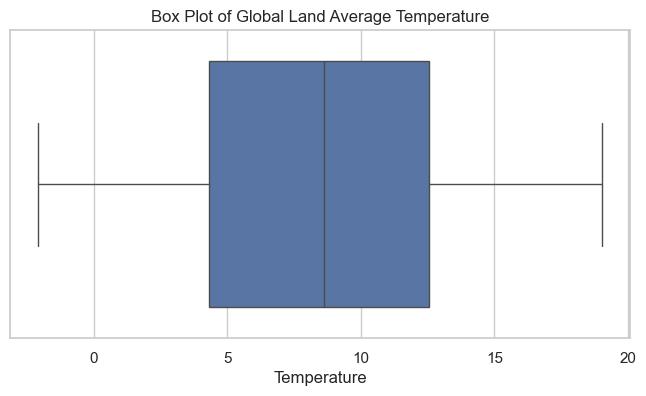

In [29]:
# Outlier CHeck
plt.figure(figsize = (8, 4))
sns.boxplot(x = global_clean["LandAverageTemperature"])
plt.title("Box Plot of Global Land Average Temperature")
plt.xlabel("Temperature")
plt.show()